In [1]:
# Celda 1 — Imports y configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Librerías cargadas correctamente")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

✅ Librerías cargadas correctamente
Pandas: 3.0.3
NumPy: 2.3.5


In [5]:
# Celda 2 — Cargar dataset
df = pd.read_csv("../data/framingham_heart_study.csv")
print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

✅ Dataset cargado: 4240 filas, 16 columnas


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
# Celda 3 — Análisis general
print("=== INFORMACIÓN DEL DATASET ===")
print(df.info())
print("\n=== VALORES NULOS ===")
print(df.isnull().sum())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().round(2)

=== INFORMACIÓN DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 5

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.00,4240.00,4135.00,4240.00,4211.00,4187.00,4240.00,4240.00,4240.00,4190.00,4240.00,4240.00,4221.00,4239.00,3852.00,4240.00
mean,0.43,49.58,1.98,0.49,9.01,0.03,0.01,0.31,0.03,236.70,132.35,82.90,25.80,75.88,81.96,0.15
std,0.50,8.57,1.02,0.50,11.92,0.17,0.08,0.46,0.16,44.59,22.03,11.91,4.08,12.03,23.95,0.36
min,0.00,32.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,107.00,83.50,48.00,15.54,44.00,40.00,0.00
25%,0.00,42.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,206.00,117.00,75.00,23.07,68.00,71.00,0.00
50%,0.00,49.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,234.00,128.00,82.00,25.40,75.00,78.00,0.00
75%,1.00,56.00,3.00,1.00,20.00,0.00,0.00,1.00,0.00,263.00,144.00,90.00,28.04,83.00,87.00,0.00
max,1.00,70.00,4.00,1.00,70.00,1.00,1.00,1.00,1.00,696.00,295.00,142.50,56.80,143.00,394.00,1.00


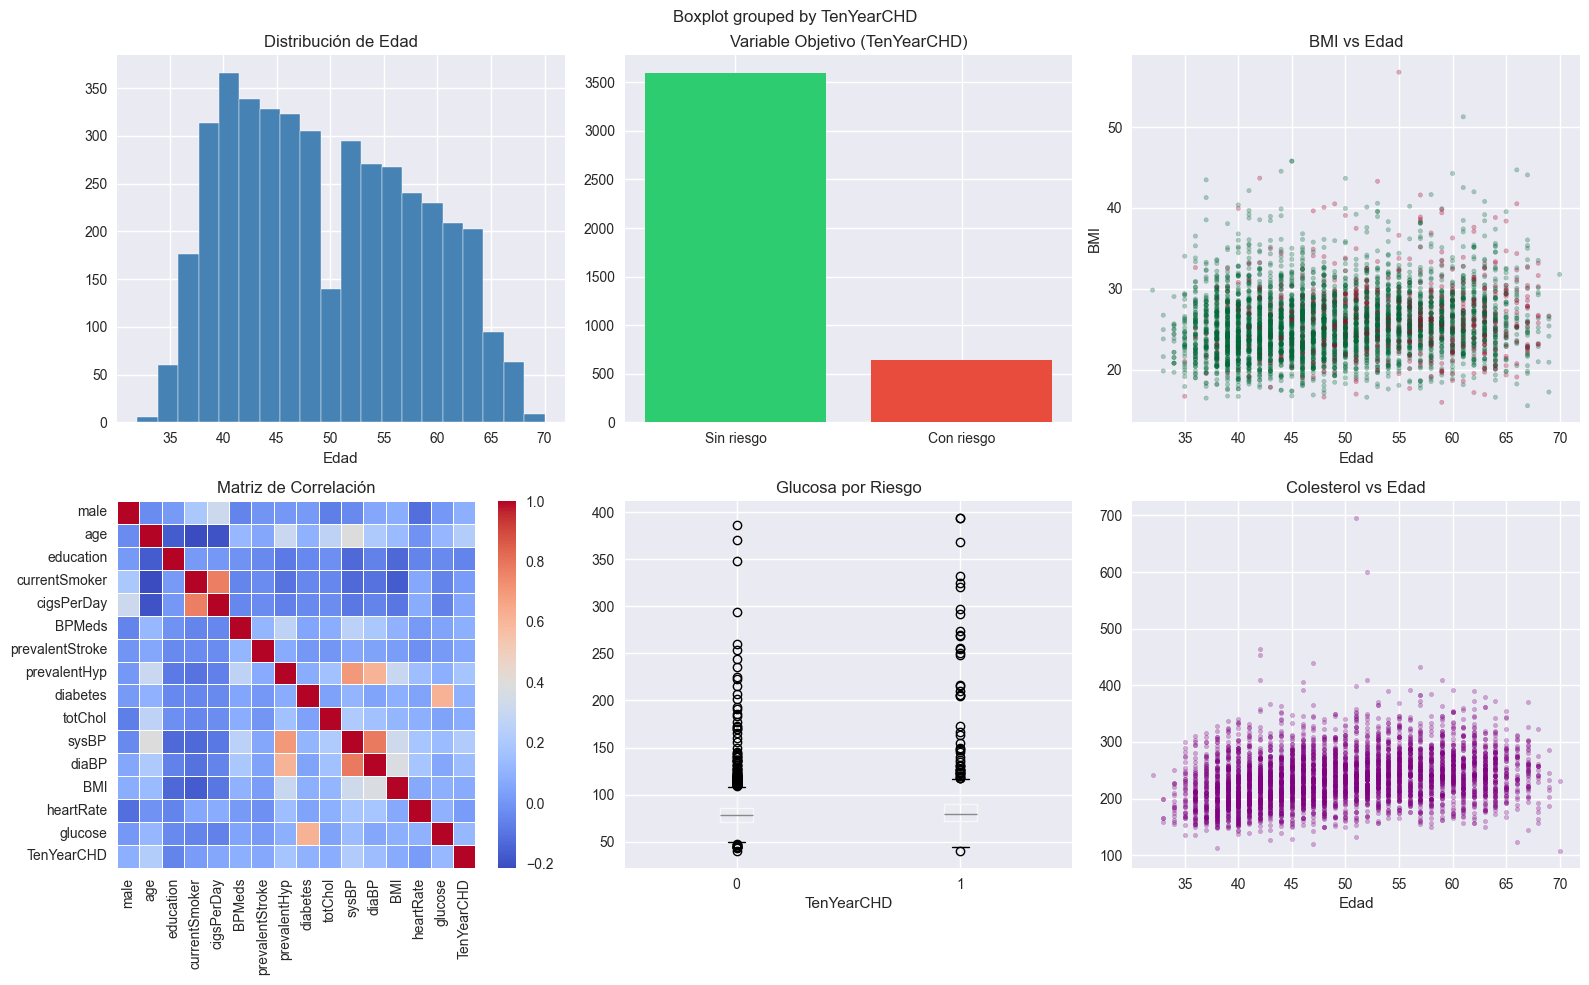

✅ Gráfico guardado en reports/


In [7]:
# Celda 4 — Visualizaciones EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('MedRisk AI — Análisis Exploratorio', fontsize=16, fontweight='bold')

# Distribución de edad
axes[0,0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad')

# Riesgo cardiovascular
counts = df['TenYearCHD'].value_counts()
axes[0,1].bar(['Sin riesgo', 'Con riesgo'], counts.values, color=['#2ecc71','#e74c3c'])
axes[0,1].set_title('Variable Objetivo (TenYearCHD)')

# BMI vs edad
axes[0,2].scatter(df['age'], df['BMI'], alpha=0.3, c=df['TenYearCHD'], cmap='RdYlGn_r', s=10)
axes[0,2].set_title('BMI vs Edad')
axes[0,2].set_xlabel('Edad')
axes[0,2].set_ylabel('BMI')

# Correlación
corr = df.corr(numeric_only=True)
sns.heatmap(corr, ax=axes[1,0], cmap='coolwarm', annot=False, linewidths=0.5)
axes[1,0].set_title('Matriz de Correlación')

# Glucosa por riesgo
df.boxplot(column='glucose', by='TenYearCHD', ax=axes[1,1])
axes[1,1].set_title('Glucosa por Riesgo')
axes[1,1].set_xlabel('TenYearCHD')

# Colesterol por edad
axes[1,2].scatter(df['age'], df['totChol'], alpha=0.3, color='purple', s=10)
axes[1,2].set_title('Colesterol vs Edad')
axes[1,2].set_xlabel('Edad')

plt.tight_layout()
plt.savefig('../reports/EDA_visualizaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en reports/")

In [8]:
# Celda 5 — Conclusiones del EDA
print("""
=== CONCLUSIONES DEL EDA ===

1. DATASET: 4,240 pacientes, 16 variables clínicas
2. DESBALANCE: Solo el 15% tiene evento cardiovascular → necesitaremos SMOTE
3. NULOS: glucose (9%), education (2%), BPMeds (1%) → imputación necesaria
4. CORRELACIONES CLAVE:
   - age        → TenYearCHD ✅
   - sysBP      → TenYearCHD ✅  
   - glucose    → TenYearCHD ✅
   - cigsPerDay → TenYearCHD ✅
5. PRÓXIMO PASO: Feature Engineering + limpieza de nulos
""")


=== CONCLUSIONES DEL EDA ===

1. DATASET: 4,240 pacientes, 16 variables clínicas
2. DESBALANCE: Solo el 15% tiene evento cardiovascular → necesitaremos SMOTE
3. NULOS: glucose (9%), education (2%), BPMeds (1%) → imputación necesaria
4. CORRELACIONES CLAVE:
   - age        → TenYearCHD ✅
   - sysBP      → TenYearCHD ✅  
   - glucose    → TenYearCHD ✅
   - cigsPerDay → TenYearCHD ✅
5. PRÓXIMO PASO: Feature Engineering + limpieza de nulos

